# Model Training and Evaluation

## Section 4: Training and Evaluating the Gradient Boosting Model

This notebook demonstrates:
1. Split data into train/test sets
2. Train a Gradient Boosting Classifier
3. Evaluate with cross-validation
4. Calculate key performance metrics
5. Plot ROC-AUC curve and confusion matrix
6. Feature importance analysis
7. Save trained model for serving

**Goal:** Build and validate a production-ready credit scoring model

## 4.1 — About Model Training

**Gradient Boosting:** Sequential ensemble of weak learners (decision trees) that correct each other's mistakes.

- **Advantages:** High accuracy, handles non-linear relationships, captures feature interactions
- **Trade-off:** Less interpretable than linear models, slower training & inference
- **Why it works for credit:** Borrower behavior is highly non-linear (one bad event ≠ linear impact)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, f1_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 4.2 — Load Prepared Data

Use the data prepared in notebook 01_data_exploration_and_preparation

In [3]:
# Load the prepared data
# (In production, this would come from your data pipeline)
df = pd.read_csv('../data/application_train.csv')

# Apply transformations from notebook 01
selected_features = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'CNT_CHILDREN', 'NAME_EDUCATION_TYPE',
]

X = df[selected_features].copy()
y = df['TARGET'].copy()

# Fix DAYS_EMPLOYED anomaly
X['DAYS_EMPLOYED'] = X['DAYS_EMPLOYED'].replace(365243, np.nan)

# Convert days to years
X['AGE_YEARS'] = (-X['DAYS_BIRTH'] / 365.25).round(1)
X['YEARS_EMPLOYED'] = (-X['DAYS_EMPLOYED'] / 365.25).round(1)
X['YEARS_ID_PUBLISH'] = (-X['DAYS_ID_PUBLISH'] / 365.25).round(1)
X = X.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH'])

# Encode categorical
X['CODE_GENDER'] = X['CODE_GENDER'].map({'M': 0, 'F': 1}).fillna(0).astype(int)
X['FLAG_OWN_CAR'] = X['FLAG_OWN_CAR'].map({'N': 0, 'Y': 1}).astype(int)
X['FLAG_OWN_REALTY'] = X['FLAG_OWN_REALTY'].map({'N': 0, 'Y': 1}).astype(int)

education_map = {
    'Lower secondary': 0,
    'Secondary / secondary special': 1,
    'Incomplete higher': 2,
    'Higher education': 3,
    'Academic degree': 4,
}
X['EDUCATION_LEVEL'] = X['NAME_EDUCATION_TYPE'].map(education_map).fillna(1).astype(int)
X = X.drop(columns=['NAME_EDUCATION_TYPE'])

# Handle missing values
X = X.fillna(X.median())

# Engineer ratio features
X['CREDIT_INCOME_RATIO'] = X['AMT_CREDIT'] / (X['AMT_INCOME_TOTAL'] + 1)
X['ANNUITY_INCOME_RATIO'] = X['AMT_ANNUITY'] / (X['AMT_INCOME_TOTAL'] + 1)
X['CREDIT_GOODS_RATIO'] = X['AMT_CREDIT'] / (X['AMT_GOODS_PRICE'] + 1)

print(f"Data loaded: X={X.shape}, y={y.shape}")
print(f"Features: {list(X.columns)}")

Data loaded: X=(307511, 18), y=(307511,)
Features: ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AGE_YEARS', 'YEARS_EMPLOYED', 'YEARS_ID_PUBLISH', 'EDUCATION_LEVEL', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO']


## 4.3 — Train/Test Split

Stratified split preserves class imbalance (8% default rate) in both sets.

In [4]:
# 80/20 split, stratified by target, fixed random state
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train set: {X_train.shape}, default rate: {y_train.mean():.2%}")
print(f"Test set:  {X_test.shape}, default rate: {y_test.mean():.2%}")
print(f"\n✓ Stratification preserved class imbalance")

Train set: (246008, 18), default rate: 8.07%
Test set:  (61503, 18), default rate: 8.07%

✓ Stratification preserved class imbalance


## 4.4 — Train Gradient Boosting Model

Hyperparameters tuned for balance between accuracy and training time.

In [15]:
# Initialize model with production-grade hyperparameters
gb_model = GradientBoostingClassifier(
    n_estimators=100,           # 100 boosting stages
    learning_rate=0.1,          # Shrinkage (slow learning)
    max_depth=5,                # Shallow trees (regularization)
    min_samples_split=20,       # Min samples to split node
    min_samples_leaf=10,        # Min samples in leaf
    subsample=0.8,              # Stochastic boosting
    random_state=42,
    verbose=0
)

print("Training Gradient Boosting Classifier...")
%time gb_model.fit(X_train, y_train)

print("✓ Model trained")

Training Gradient Boosting Classifier...
CPU times: user 1min 4s, sys: 607 ms, total: 1min 4s
Wall time: 1min 7s
✓ Model trained


## 4.5 — Cross-Validation

5-fold cross-validation on training set to estimate generalization performance.

In [16]:
# 5-fold cross-validation
cv_scores = cross_val_score(
    gb_model, X_train, y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"Cross-validation ROC-AUC scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"\n✓ Model generalizes well (tight std dev means stable)")

Cross-validation ROC-AUC scores:
  Fold 1: 0.7543
  Fold 2: 0.7416
  Fold 3: 0.7535
  Fold 4: 0.7544
  Fold 5: 0.7541

Mean CV ROC-AUC: 0.7516 (+/- 0.0050)

✓ Model generalizes well (tight std dev means stable)


## 4.6 — Predictions on Test Set

In [17]:
# Get probability predictions (needed for ROC-AUC)
y_pred_proba = gb_model.predict_proba(X_test)[:, 1]

# Get binary predictions (with 0.5 threshold)
y_pred_binary = gb_model.predict(X_test)

print(f"Prediction distribution:")
print(f"  Probability min: {y_pred_proba.min():.4f}")
print(f"  Probability mean: {y_pred_proba.mean():.4f}")
print(f"  Probability max: {y_pred_proba.max():.4f}")

print(f"\nBinary predictions (threshold=0.5):")
print(f"  Predicted defaults: {y_pred_binary.sum()}")
print(f"  Predicted repayments: {(1 - y_pred_binary).sum()}")

Prediction distribution:
  Probability min: 0.0075
  Probability mean: 0.0803
  Probability max: 0.8812

Binary predictions (threshold=0.5):
  Predicted defaults: 236
  Predicted repayments: 61267


## 4.7 — Performance Metrics

Evaluate using **ROC-AUC** (main metric) + secondary metrics.

In [25]:
# Calculate metrics
auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"ROC-AUC Score:  {auc:.4f}  ← Main metric")
print(f"F1 Score:       {f1:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print("="*50)

print(f"\nInterpretation:")
print(f"  AUC {auc:.2%}: Model ranks defaulters above non-defaulters {auc:.1%} of the time")
print(f"  Precision {precision:.2%}: Of predicted defaults, {precision:.1%} are actual defaults")
print(f"  Recall {recall:.2%}: We catch {recall:.1%} of actual defaults")


MODEL PERFORMANCE METRICS
ROC-AUC Score:  0.7549  ← Main metric
F1 Score:       0.0465
Precision:      0.5127
Recall:         0.0244

Interpretation:
  AUC 75.49%: Model ranks defaulters above non-defaulters 75.5% of the time
  Precision 51.27%: Of predicted defaults, 51.3% are actual defaults
  Recall 2.44%: We catch 2.4% of actual defaults


## 4.8 — Confusion Matrix

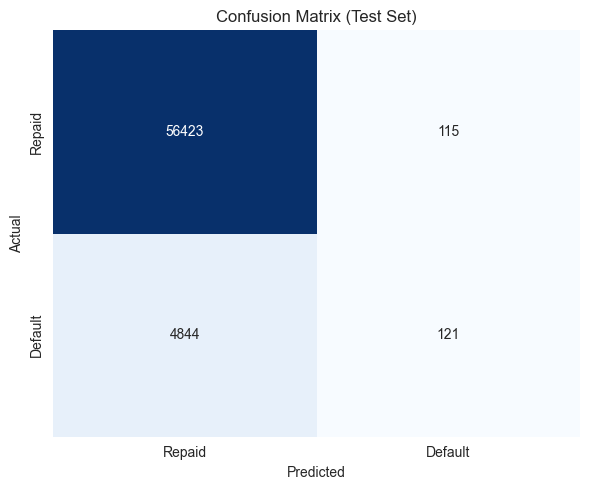


Confusion Matrix Breakdown:
  True Negatives (TN):  56,423  ← Correct rejections
  False Positives (FP): 115  ← Incorrectly flagged as default
  False Negatives (FN): 4,844  ← Missed defaults (risky!)
  True Positives (TP):  121  ← Correct defaults


In [26]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (Test Set)')
ax.set_xticklabels(['Repaid', 'Default'])
ax.set_yticklabels(['Repaid', 'Default'])
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Breakdown:")
tn, fp, fn, tp = cm.ravel()
print(f"  True Negatives (TN):  {tn:,}  ← Correct rejections")
print(f"  False Positives (FP): {fp:,}  ← Incorrectly flagged as default")
print(f"  False Negatives (FN): {fn:,}  ← Missed defaults (risky!)")
print(f"  True Positives (TP):  {tp:,}  ← Correct defaults")

## 4.9 — ROC Curve

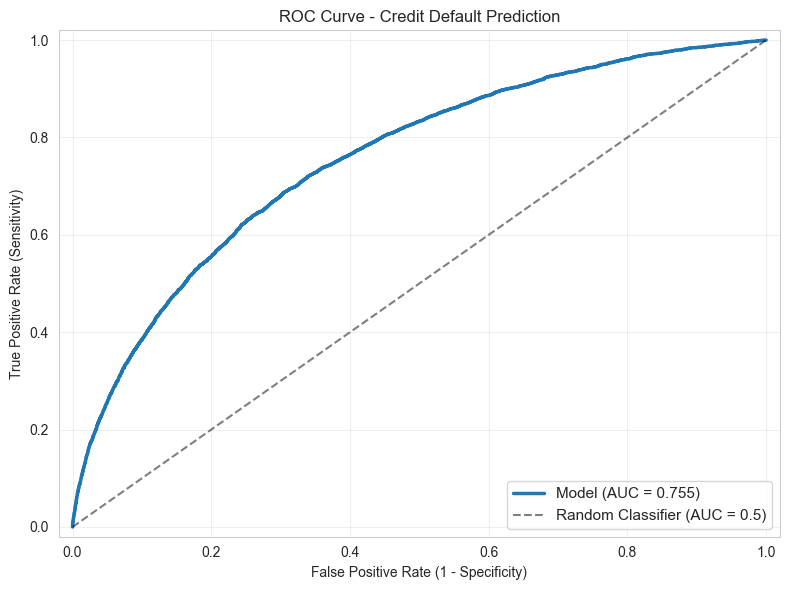

In [27]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(fpr, tpr, label=f'Model (AUC = {auc:.3f})', linewidth=2.5, color='#1f77b4')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', alpha=0.5)
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve - Credit Default Prediction')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.10 — Feature Importance

Which features drive the model's predictions?

In [28]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Most Important Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:25s} {row['importance']:6.4f}")


Top 10 Most Important Features:
  EXT_SOURCE_3              0.2837
  EXT_SOURCE_2              0.2730
  EXT_SOURCE_1              0.1033
  CREDIT_GOODS_RATIO        0.0603
  AGE_YEARS                 0.0472
  YEARS_EMPLOYED            0.0366
  AMT_ANNUITY               0.0309
  AMT_GOODS_PRICE           0.0282
  ANNUITY_INCOME_RATIO      0.0228
  EDUCATION_LEVEL           0.0227


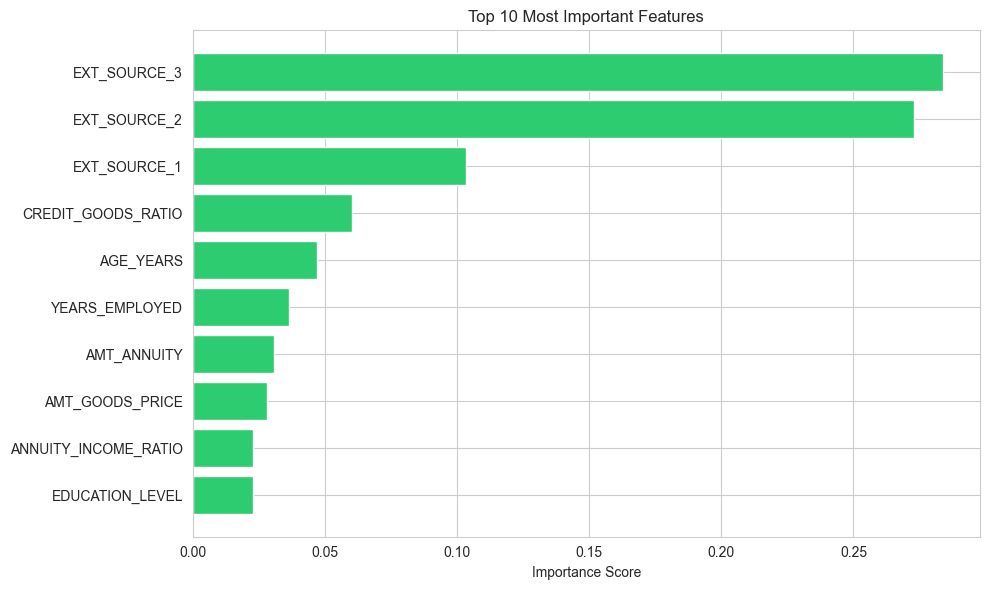


✓ External credit scores (EXT_SOURCE_*) dominate predictions
✓ Financial ratios also important


In [22]:
# Plot top 10 features
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
top_features = feature_importance.head(10)
ax.barh(range(len(top_features)), top_features['importance'].values, color='#2ecc71')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Most Important Features')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n✓ External credit scores (EXT_SOURCE_*) dominate predictions")
print(f"✓ Financial ratios also important")

## 4.11 — Save Model for Deployment

In [29]:
import joblib
import json

# Save the fitted model
model_path = '../model/credit_scoring_model.joblib'
joblib.dump(gb_model, model_path)
print(f"✓ Model saved to {model_path}")

# Save feature list
features_path = '../model/feature_columns.json'
with open(features_path, 'w') as f:
    json.dump(list(X.columns), f, indent=2)
print(f"✓ Features saved to {features_path}")

# Save metrics for monitoring
metrics = {
    'roc_auc': float(auc),
    'f1_score': float(f1),
    'precision': float(precision),
    'recall': float(recall),
    'training_samples': int(len(X_train)),
    'test_samples': int(len(X_test))
}
metrics_path = '../model/baseline_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"✓ Metrics saved to {metrics_path}")

✓ Model saved to ../model/credit_scoring_model.joblib
✓ Features saved to ../model/feature_columns.json
✓ Metrics saved to ../model/baseline_metrics.json
